# Notebook 01 — Data Pipeline
### xG Spread Mean-Reversion Model · Premier League 2015–2025

---

## Purpose

This notebook downloads Premier League Expected Goals (xG) data, constructs the xG spread time series for each team, and prepares a clean team-level dataset for the Ornstein-Uhlenbeck (O-U) parameter estimation in Notebook 02.

---

## What Is the xG Spread?

Expected Goals (xG) quantifies the quality of chances a team creates. Each shot is assigned a probability of scoring based on position, angle, and assist type. Summing those probabilities gives the number of goals a team *should* have scored.

Every match produces two numbers for each team:

- xG — the quality of chances created

- Goals — what the team actually scored

The difference between them, xG − goals, is the spread. The spread behaves like a noisy, mean‑reverting process. Teams that consistently under‑ or over‑perform their xG tend to drift back toward their long‑run average over time.

The **xG spread** is calculated by:

```
spread(t)  =  xG(t)  −  Goals(t)

```

- **Positive spread:** The team is *under-converting* — creating more expected value than their goals reflect. Theory predicts reversion: finishing regresses to the mean, defenders adjust, lucky opponents run out of luck.

- **Negative spread:** The team is *over-converting* — scoring more than their chances warrant. Equally unsustainable.

This is the football equivalent of the **clean spark spread** in energy markets: the difference between the price implied by gas fundamentals and the actual market price. Both are mean-reverting processes pulled toward equilibrium by structural forces.

---

## Data Source

Data comes from Understat, which provides match‑level xG and goal information for the Premier League. Understat returns nested JSON‑like structures embedded as strings, so part of this notebook’s job is to parse and flatten those fields into usable columns.

- **Coverage:** Premier League seasons 2015–16 through 2024–25 (10 seasons)
- **Volume:** 3,800 matches · 34 teams (reflecting promotion and relegation)
- **Format:** Match-level home/away xG and goals

## Load or Download the Raw Data

If a clean CSV already exists locally load the CSV directly. Otherwise, download the raw match data from Understat, season by season, and save it for reproducibility.

This ensures the pipeline is deterministic and can be run offline once the data is cached.

In [1]:
import pandas as pd
import aiohttp
from understat import Understat

from pathlib import Path

# Notebook directory
THIS_DIR = Path().resolve()

# Project root = parent of the notebooks folder
PROJECT_ROOT = THIS_DIR.parent

DATA_DIR = PROJECT_ROOT / "data"
FIG_DIR = PROJECT_ROOT / "figures"

DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

DATA_FILE = DATA_DIR / "pl_match_xg_2015_2025.csv"

PROJECT_ROOT



# -----------------------------
# Async Understat fetchers
# -----------------------------
async def fetch_season(session, year):
    u = Understat(session)
    matches = await u.get_league_results("EPL", year)
    return pd.DataFrame(matches)

async def fetch_all():
    all_dfs = []
    async with aiohttp.ClientSession() as session:
        for year in range(2015, 2025):
            print(f"Fetching {year}–{year+1}...", end=" ")
            df = await fetch_season(session, year)
            all_dfs.append(df)
            print(f"{len(df)} matches")
    return pd.concat(all_dfs, ignore_index=True)

# -----------------------------
# 1. Load or download
# -----------------------------
if DATA_FILE.exists():
    print("📁 Found existing data — loading CSV...")
    raw = pd.read_csv(DATA_FILE)
    print("Loaded. Shape:", raw.shape)

else:
    print("⬇️ No data found — downloading from Understat...")
    raw = await fetch_all()
    raw.to_csv(DATA_FILE, index=False)
    print("Saved. Shape:", raw.shape)


📁 Found existing data — loading CSV...
Loaded. Shape: (3800, 9)


## Parse Understat’s Nested Fields

Understat stores several fields — including team names, xG values, and goal counts — as nested dictionaries encoded as strings. Convert these into Python dictionaries and extract:

- home team name

- away team name

- home xG

- away xG

- home goals

- away goals

Extract the season start year (e.g., “2015/2016” → 2015) for grouping and walk‑forward logic for later in the project.

---
## Step 1 — Parse Nested API Response

The raw Understat data stores team names, goals, and xG as **nested Python dicts** embedded as strings within each row column — e.g. `goals` looks like `"{'h': '2', 'a': '1'}"`. We unpack these into clean flat columns.

After parsing, each row contains:

| Column | Type | Description |
|---|---|---|
| `id` | int | Understat match ID |
| `date` | datetime | Kick-off date and time |
| `season_start` | int | Season identifier (e.g. 2015 = 2015–16) |
| `home_team` / `away_team` | str | Team names |
| `home_goals` / `away_goals` | int | Full-time goals |
| `home_xg` / `away_xg` | float | Understat expected goals |

In [2]:
# ─────────────────────────────────────────────────────────────────
# CELL 2 — Parse and clean raw API response
# ─────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import ast

# Load raw data
df_raw = pd.read_csv(DATA_DIR / "pl_match_xg_2015_2025.csv")

# Convert string-encoded dicts to real Python dicts
for col in ['h', 'a', 'goals', 'xG']:
    df_raw[col] = df_raw[col].apply(ast.literal_eval)

# Extract home/away values from each dict
df_raw['home_team']  = df_raw['h'].apply(lambda x: x['title'])
df_raw['away_team']  = df_raw['a'].apply(lambda x: x['title'])
df_raw['home_goals'] = df_raw['goals'].apply(lambda x: int(x['h']))
df_raw['away_goals'] = df_raw['goals'].apply(lambda x: int(x['a']))
df_raw['home_xg']    = df_raw['xG'].apply(lambda x: float(x['h']))
df_raw['away_xg']    = df_raw['xG'].apply(lambda x: float(x['a']))
df_raw['date']       = pd.to_datetime(df_raw['datetime'])

# Select and sort final columns
df = df_raw[['id', 'date', 'season_start',
             'home_team', 'away_team',
             'home_goals', 'away_goals',
             'home_xg', 'away_xg']].copy()
df = df.sort_values('date').reset_index(drop=True)

# Save cleaned file
df.to_csv(DATA_DIR / "pl_match_xg_clean.csv", index=False)
print(f"Saved pl_match_xg_clean.csv — shape: {df.shape}")
print(df.head(3).to_string())


Saved pl_match_xg_clean.csv — shape: (3800, 9)
   id                date  season_start          home_team    away_team  home_goals  away_goals   home_xg   away_xg
0  81 2015-08-08 15:45:00          2015  Manchester United    Tottenham           1           0  0.627539  0.674600
1  82 2015-08-08 18:00:00          2015        Bournemouth  Aston Villa           0           1  0.876106  0.782253
2  83 2015-08-08 18:00:00          2015            Everton      Watford           2           2  0.604226  0.557892


In [3]:
# ─────────────────────────────────────────────────────────────────
# CELL 3 — Reshape from match-level to team-level (long format)
# ─────────────────────────────────────────────────────────────────
#
# We create two separate dataframes — one for home teams, one for
# away teams — with identical column names, then stack them.
# Sorting by [team, date] gives each team's chronological series.

import pandas as pd
import numpy as np
import warnings

df = pd.read_csv(DATA_DIR / "pl_match_xg_clean.csv", parse_dates=['date'])


# Home perspective: rename columns to generic team/goals/xg
home = df[['id','date','season_start','home_team','home_goals','home_xg']].copy()
home.columns = ['match_id','date','season','team','goals','xg']
home['venue'] = 'home'

# Away perspective: same structure
away = df[['id','date','season_start','away_team','away_goals','away_xg']].copy()
away.columns = ['match_id','date','season','team','goals','xg']
away['venue'] = 'away'

# Stack and sort — each team now has a chronological match sequence
team_match = pd.concat([home, away]).sort_values(['team','date']).reset_index(drop=True)

# Rename look-ahead-contaminated column for safety
# z_spread is computed with future information (look-ahead).
# Keep it only for exploratory plots; never use in modelling.
team_match = team_match.rename(
    columns={'z_spread': 'z_spread_INSAMPLE_DO_NOT_USE'}
)

print(f"Shape: {team_match.shape}  (expected 7600 rows)")
print(f"Teams: {team_match['team'].nunique()}")
print(f"Seasons: {sorted(team_match['season'].unique())}")

Shape: (7600, 7)  (expected 7600 rows)
Teams: 34
Seasons: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


---
## Step 2 — Reshape to Team-Level (Long Format)

Each match currently appears as **one row** with separate home and away columns. To build each team's individual xG spread time series, we need one row **per team per match** — a standard *long format* reshape.

Arsenal vs Chelsea becomes **two rows**: one for Arsenal (with Arsenal's xG and goals), one for Chelsea (with Chelsea's xG and goals). Both rows share the same `match_id` and `date`.

**Expected result:** 3,800 matches × 2 teams = **7,600 rows**.

---
## Step 3 — Construct the xG Spread Series

Three transformations build the spread signal used by the O-U model:

**3a. Raw spread:** `xG − Goals` per match. Noisy — a single 5-goal game can dominate.

**3b. Rolling 5-match mean:** Smooths single-match noise. `min_periods=3` allows estimation from match 3 onward rather than waiting for a full window of 5. This is a deliberate choice — waiting 5 matches before generating any signal would lose the early-season dynamics where spreads are often at their most extreme.

**3c. Season z-score per team:** Normalises the rolling spread within each team-season, so that teams with different playing styles (high-press vs defensive block) are comparable. Without normalisation, a high-xG team like Man City would almost always appear to have a large spread simply because they generate more chances.

The z-score formula: `z = (rolling_spread − season_mean) / season_std`

In [4]:
# ─────────────────────────────────────────────────────────────────
# CELL 4 — Build the xG spread series
# ─────────────────────────────────────────────────────────────────
#
# Three transformations:
#   1. raw_spread     = xg - goals  (per match)
#   2. rolling_spread = 5-match rolling mean of raw_spread
#   3. z_spread       = season-level z-score of rolling_spread
#
# The warnings suppressor silences a pandas DeprecationWarning
# about groupby apply behaviour — harmless in this version.

# 3a. Raw spread: positive = under-converting, negative = over-converting
team_match['raw_spread'] = team_match['xg'] - team_match['goals']

# 3b. Rolling 5-match mean — smooths single-match variance
#     min_periods=3 allows estimation from match 3 of the season
team_match['rolling_spread'] = (
    team_match.groupby('team')['raw_spread']
    .transform(lambda x: x.rolling(window=5, min_periods=3).mean())
)

# 3c. Season z-score: normalise spread within each team-season
#     This makes spreads comparable across teams with different
#     attacking profiles and playing styles
def season_zscore(group):
    mu    = group['rolling_spread'].mean()
    sigma = group['rolling_spread'].std()
    # Guard against zero variance (rare — all identical spreads)
    group['z_spread'] = (
        (group['rolling_spread'] - mu) / sigma if sigma > 0 else 0
    )
    return group

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    team_match = team_match.groupby(
        ['team', 'season'], group_keys=False
    ).apply(season_zscore)

# Match sequence number within each team-season (1–38)
# Used to align observations in the O-U estimation
team_match['match_num'] = (
    team_match.groupby(['team','season']).cumcount() + 1
)

print(f"Spread series built. Shape: {team_match.shape}")
print(f"Columns: {team_match.columns.tolist()}")

Spread series built. Shape: (7600, 11)
Columns: ['match_id', 'date', 'season', 'team', 'goals', 'xg', 'venue', 'raw_spread', 'rolling_spread', 'z_spread', 'match_num']


---
## Step 4 — Save and Validate

Three validation checks are taken before saving:

**Check 1 — Man City 2023:** A strong team should show oscillating raw spreads with the rolling mean stabilising quickly. The z-scores should be centred near zero. This confirms the pipeline is computing correctly.

**Check 2 — Leicester 2015–16 xG/goals ratio:** This is a deliberate test of a well-known narrative. The popular claim is that Leicester's title win was a statistical fluke — they scored far more than their xG warranted. If the model shows their xG/goals ratio close to 1.0, it contradicts the luck narrative and supports genuine performance. This is a strong talking point for the project.

**Check 3 — Match count integrity:** Every team must have exactly 38 matches per season. Any gaps indicate missing data that would bias the O-U estimation downstream.

## Manchester City 2023–24: Three-Layer Spread Construction

/tmp/ipykernel_1434/111356592.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


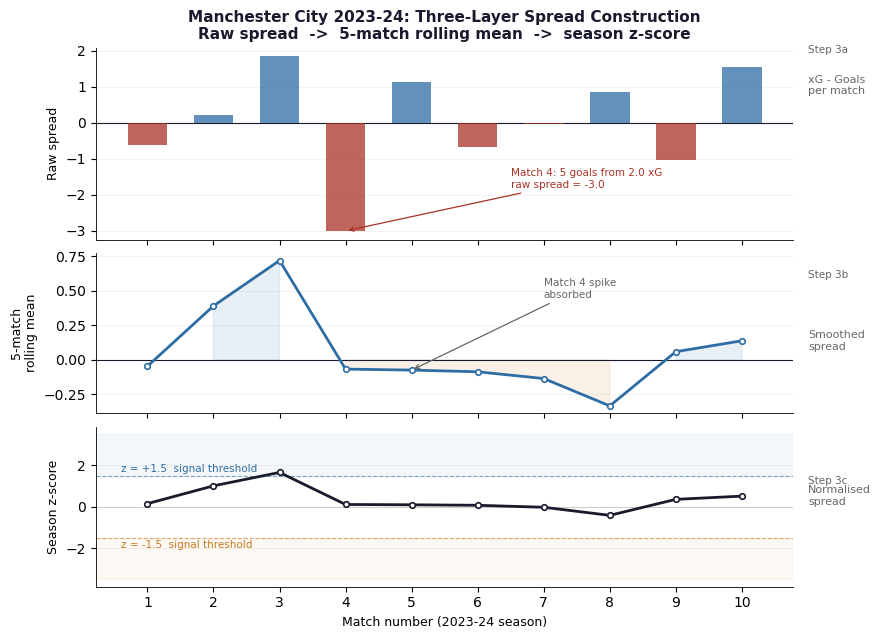

Saved nb01_fig1_spread_construction.png


In [5]:
# -----------------------------------------------------------------
# FIGURE 1 — Three-layer spread construction: Man City 2023-24
# -----------------------------------------------------------------
#
# Tufte principles applied:
#   Small multiples with shared x-axis: same data, three resolutions
#   Minimal decoration: gridlines on y-axis only, no top/right spines
#   Direct labels on right margin eliminate legend clutter
#   Step labels (3a/3b/3c) connect panels to notebook text
#   Annotation marks the Match 4 noise event that Step 3b absorbs
#
# Reads: team_match (built in Cell 4)

import matplotlib.pyplot as plt

DARK  = '#1a1a2e'
BLUE  = '#2E6DA4'
AMBER = '#C97A20'
RED   = '#A93226'
GREEN = '#1E8449'
GREY  = '#666666'
LGREY = '#CCCCCC'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.6,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

# Extract Man City 2023-24, first 10 matches
mc = (
    team_match[
        (team_match['team'] == 'Manchester City') &
        (team_match['season'] == 2023)
    ]
    .sort_values('date')
    .head(10)
    .reset_index(drop=True)
)
mc['match_num'] = mc.index + 1
x = mc['match_num'].values

# Three stacked panels sharing the x-axis
fig, axes = plt.subplots(
    3, 1, figsize=(9, 7),
    sharex=True,
    gridspec_kw={'hspace': 0.08, 'height_ratios': [1.2, 1, 1]}
)

# Panel 1: Raw spread
ax = axes[0]
bar_colours = [RED if v < 0 else BLUE for v in mc['raw_spread']]
ax.bar(x, mc['raw_spread'], color=bar_colours, alpha=0.75, width=0.6, zorder=3)
ax.axhline(0, color=DARK, linewidth=0.8, zorder=2)
ax.yaxis.grid(True, zorder=0, linewidth=0.4, color='#EBEBEB')
ax.set_axisbelow(True)
ax.set_ylabel('Raw spread', fontsize=9, labelpad=4)
ax.text(11.0, mc['raw_spread'].iloc[-1] - 0.5,
        'xG - Goals\nper match', fontsize=8, color=GREY, va='center')
ax.text(11.0, mc['raw_spread'].max() * 0.9 + 0.5,
        'Step 3a', fontsize=7.5, color=GREY, va='top')
ax.annotate(
    f"Match 4: 5 goals from 2.0 xG\nraw spread = {mc.loc[3,'raw_spread']:.1f}",
    xy=(4, mc.loc[3, 'raw_spread']),
    xytext=(6.5, -1.8),
    fontsize=7.5, color=RED,
    arrowprops=dict(arrowstyle='->', color=RED, lw=0.9)
)

# Panel 2: Rolling 5-match mean
ax = axes[1]
ax.plot(x, mc['rolling_spread'], color=BLUE, linewidth=2, zorder=3,
        marker='o', markersize=4,
        markerfacecolor='white', markeredgecolor=BLUE, markeredgewidth=1.2)
ax.axhline(0, color=DARK, linewidth=0.8, zorder=2)
ax.fill_between(x, 0, mc['rolling_spread'],
                where=mc['rolling_spread'] >= 0, alpha=0.10, color=BLUE)
ax.fill_between(x, 0, mc['rolling_spread'],
                where=mc['rolling_spread'] < 0,  alpha=0.10, color=AMBER)
ax.yaxis.grid(True, zorder=0, linewidth=0.4, color='#EBEBEB')
ax.set_axisbelow(True)
ax.set_ylabel('5-match\nrolling mean', fontsize=9, labelpad=4)
ax.text(11.0, mc['rolling_spread'].iloc[-1],
        'Smoothed\nspread', fontsize=8, color=GREY, va='center')
ax.text(11.0, mc['rolling_spread'].max() * 0.9,
        'Step 3b', fontsize=7.5, color=GREY, va='top')
ax.annotate(
    'Match 4 spike\nabsorbed',
    xy=(5, mc.loc[4, 'rolling_spread']),
    xytext=(7, 0.45),
    fontsize=7.5, color=GREY,
    arrowprops=dict(arrowstyle='->', color=GREY, lw=0.9)
)

# Panel 3: Season z-score
ax = axes[2]
thresh = 1.5
ax.axhspan( thresh,  3.5, alpha=0.05, color=BLUE,  zorder=1)
ax.axhspan(-3.5, -thresh, alpha=0.05, color=AMBER, zorder=1)
ax.plot(x, mc['z_spread'], color=DARK, linewidth=2, zorder=3,
        marker='o', markersize=4,
        markerfacecolor='white', markeredgecolor=DARK, markeredgewidth=1.2)
ax.axhline(0, color=LGREY, linewidth=0.8, zorder=2)
ax.axhline( thresh, color=BLUE,  linewidth=0.8, linestyle='--', alpha=0.6)
ax.axhline(-thresh, color=AMBER, linewidth=0.8, linestyle='--', alpha=0.6)
ax.text(0.6, thresh + 0.08, 'z = +1.5  signal threshold',
        fontsize=7.5, color=BLUE, va='bottom')
ax.text(0.6, -thresh - 0.08, 'z = -1.5  signal threshold',
        fontsize=7.5, color=AMBER, va='top')
ax.yaxis.grid(True, zorder=0, linewidth=0.4, color='#EBEBEB')
ax.set_axisbelow(True)
ax.set_ylabel('Season z-score', fontsize=9, labelpad=4)
ax.set_xlabel('Match number (2023-24 season)', fontsize=9)
ax.set_xticks(x)
ax.text(11.0, mc['z_spread'].iloc[-1],
        'Normalised\nspread', fontsize=8, color=GREY, va='center')
ax.text(11.0, mc['z_spread'].max() * 0.9,
        'Step 3c', fontsize=7.5, color=GREY, va='top')

axes[0].set_title(
    'Manchester City 2023-24: Three-Layer Spread Construction\n'
    'Raw spread  ->  5-match rolling mean  ->  season z-score',
    fontsize=11, fontweight='bold', color=DARK
)

plt.tight_layout()
plt.savefig(FIG_DIR / 'nb01_fig1_spread_construction.png')
plt.show()
print("Saved nb01_fig1_spread_construction.png")


### Figure 1 — Manchester City 2023–24: Three-Layer Spread Construction

The spread is not used raw. Three transformations convert noisy
match-level data into the signal that feeds the O-U model:

**Step 3a — Raw spread** (`xG - Goals` per match) is volatile. A
single high-scoring match can dominate the picture. Match 4 in this
example — City scored 5 goals from just 2.0 xG — produces a raw
spread of -3.0, a reading that would trigger a false signal if used
directly.

**Step 3b — 5-match rolling mean** smooths this noise. The 5-goal
anomaly from Match 4 is absorbed within two matches. The rolling mean
reveals the underlying drift: City were broadly in equilibrium across
this period.

**Step 3c — Season z-score** normalises the rolling mean against the
season's own distribution. A high-pressing side generating 2.5 xG per
match and a defensive side generating 1.0 xG per match both become
interpretable on the same scale. The dashed lines mark the +/-1.5
signal threshold used in Notebooks 05A and 05B.

The three panels share an x-axis: the same 10 matches, viewed at
increasing levels of abstraction.


In [6]:
# ─────────────────────────────────────────────────────────────────
# CELL 5 — Save dataset and run validation checks
# ─────────────────────────────────────────────────────────────────
#
# Three checks:
#   1. Man City 2023 sample  — confirms spread calculation
#   2. Leicester 2015 ratio  — tests popular luck narrative
#   3. Match count integrity — confirms complete dataset

team_match.to_csv(DATA_DIR / "pl_team_match_spread.csv", index=False)

print(f"Saved pl_team_match_spread.csv — shape: {team_match.shape}")

# ── Check 1: Man City 2023 ─────────────────────────────────────────────────
# Raw spreads should oscillate match-to-match; rolling spread stabilises;
# z-scores should centre around zero across the season
print("\n── Check 1: Man City 2023 (first 10 matches) ─────────────────")
print(team_match[
    (team_match['team'] == 'Manchester City') &
    (team_match['season'] == 2023)
][['date','match_num','goals','xg','raw_spread','rolling_spread','z_spread']]
.head(10).to_string())

# ── Check 2: Leicester 2015 xG/goals ratio ─────────────────────────────────
# ratio = total_xg / total_goals
#   ~1.0 = scored what chances predicted  → genuine performance
#   >1.0 = xG exceeded goals             → under-converted (unlucky)
#   <1.0 = goals exceeded xG             → over-converted  (fortunate)
# The popular narrative says Leicester were lucky. If their ratio is ~1.0,
# the data says otherwise.
print("\n── Check 2: Season xG/Goals ratio — 2015–16 ──────────────────")
print("  (ratio ~1.0 = genuine; >1.0 = unlucky; <1.0 = fortunate)")
season_check = team_match.groupby(['team','season']).agg(
    total_xg   =('xg','sum'),
    total_goals=('goals','sum'),
    matches    =('match_id','count')
).reset_index()
season_check['xg_goals_ratio'] = (
    season_check['total_xg'] / season_check['total_goals'].replace(0, np.nan)
)
print(season_check[season_check['season'] == 2015]
      .sort_values('xg_goals_ratio', ascending=False)
      [['team','total_xg','total_goals','xg_goals_ratio']]
      .to_string())

# ── Check 3: Match count integrity ─────────────────────────────────────────
# Every team must have exactly 38 matches per season.
# Anything less indicates a gap in the Understat data.
print("\n── Check 3: Match counts per team per season ──────────────────")
match_counts = team_match.groupby(['team','season'])['match_id'].count()
print(f"  Min: {match_counts.min()}   Max: {match_counts.max()}")
unusual = match_counts[match_counts != 38]
if len(unusual) > 0:
    print("  ⚠ Teams with != 38 matches:")
    print(unusual)
else:
    print("  ✓ All teams have exactly 38 matches per season")

Saved pl_team_match_spread.csv — shape: (7600, 11)

── Check 1: Man City 2023 (first 10 matches) ─────────────────
                    date  match_num  goals        xg  raw_spread  rolling_spread  z_spread
4370 2023-08-11 19:00:00          1      3  2.400740   -0.599260       -0.046818  0.150569
4371 2023-08-19 19:00:00          2      1  1.225280    0.225280        0.389562  1.007336
4372 2023-08-27 13:00:00          3      2  3.848040    1.848040        0.718056  1.652286
4373 2023-09-02 14:00:00          4      5  2.001520   -2.998480       -0.067586  0.109794
4374 2023-09-16 14:00:00          5      3  4.150460    1.150460       -0.074792  0.095646
4375 2023-09-23 14:00:00          6      2  1.339840   -0.660160       -0.086972  0.071732
4376 2023-09-30 14:00:00          7      1  0.980750   -0.019250       -0.135878 -0.024288
4377 2023-10-08 15:30:00          8      0  0.858071    0.858071       -0.333872 -0.413019
4378 2023-10-21 14:00:00          9      2  0.962509   -1.037491  

## Premier League 2015–16: xG / Goals Ratio

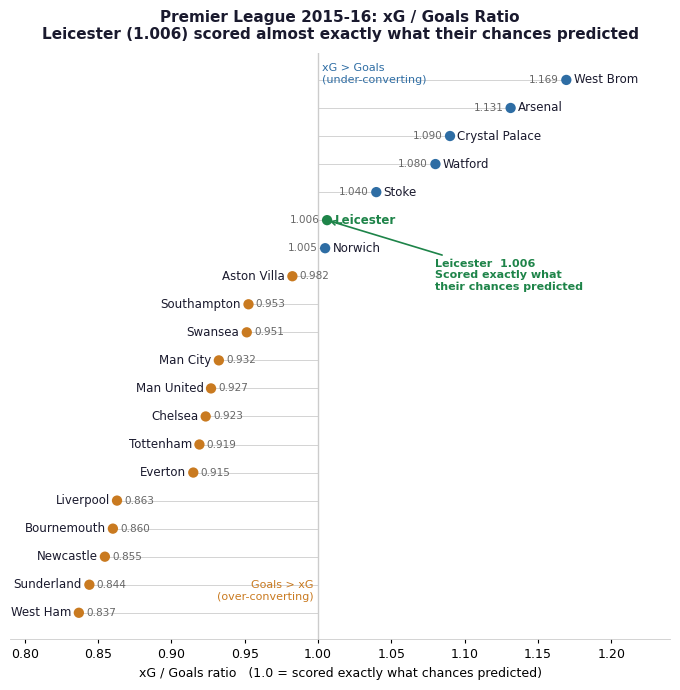

Saved nb01_fig2_xg_goals_ratio.png


In [7]:
# -----------------------------------------------------------------
# FIGURE 2 — xG / Goals ratio: Premier League 2015-16
# -----------------------------------------------------------------
#
# Tufte principles applied:
#   Cleveland dot plot: ranked order, reference line, connector lines
#   No bars — dots encode position more precisely than bar length
#   Direct labels eliminate the need for a legend
#   Minimal decoration: no top/right/left spines, grey connectors
#   Colour encodes meaning only:
#     blue  = under-converting (xG > Goals)
#     amber = over-converting  (Goals > xG)
#     green = Leicester (the key case study)
#
# Reads: season_check (built in Cell 5)

import matplotlib.pyplot as plt
import numpy as np

# Style constants — reused across all figures in this notebook
DARK  = '#1a1a2e'
BLUE  = '#2E6DA4'
AMBER = '#C97A20'
RED   = '#A93226'
GREEN = '#1E8449'
GREY  = '#666666'
LGREY = '#CCCCCC'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.spines.left':  False,
    'axes.linewidth':    0.6,
    'axes.labelsize':    10,
    'axes.titlesize':    11,
    'axes.titleweight':  'bold',
    'axes.titlepad':     10,
    'xtick.major.size':  3,
    'ytick.major.size':  0,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

# Data: 2015-16 ratios from season_check built in Cell 5
ratio_2015 = (
    season_check[season_check['season'] == 2015]
    [['team', 'total_xg', 'total_goals', 'xg_goals_ratio']]
    .sort_values('xg_goals_ratio', ascending=True)
    .reset_index(drop=True)
)

# Shorten team names for readability
name_map = {
    'Manchester City':      'Man City',
    'Manchester United':    'Man United',
    'West Bromwich Albion': 'West Brom',
    'Newcastle United':     'Newcastle',
}
ratio_2015['display'] = ratio_2015['team'].replace(name_map)

fig, ax = plt.subplots(figsize=(7, 7))

y      = np.arange(len(ratio_2015))
ratios = ratio_2015['xg_goals_ratio'].values
teams  = ratio_2015['display'].values

# Colour: Leicester green, >1.0 blue, <1.0 amber
colours = []
for t, r in zip(teams, ratios):
    if t == 'Leicester':
        colours.append(GREEN)
    elif r > 1.0:
        colours.append(BLUE)
    else:
        colours.append(AMBER)

# Reference line at 1.0
ax.axvline(1.0, color=LGREY, linewidth=1.0, zorder=1)

# Connector lines from reference to each dot
for yi, ri in zip(y, ratios):
    ax.plot([1.0, ri], [yi, yi], color=LGREY, linewidth=0.6, zorder=2)

# Dots
ax.scatter(ratios, y, c=colours, s=55, zorder=3, edgecolors='none')

# Team name labels (right of dot if >1.0, left if <1.0)
for yi, team, ratio, colour in zip(y, teams, ratios, colours):
    is_right = ratio >= 1.0
    offset   = 0.005 if is_right else -0.005
    ha       = 'left' if is_right else 'right'
    weight   = 'bold' if team == 'Leicester' else 'normal'
    ax.text(ratio + offset, yi, team,
            va='center', ha=ha, fontsize=8.5,
            color=GREEN if team == 'Leicester' else DARK,
            fontweight=weight)

# Ratio value labels on the opposite side
for yi, ratio in zip(y, ratios):
    is_right = ratio >= 1.0
    offset   = -0.005 if is_right else 0.005
    ha       = 'right' if is_right else 'left'
    ax.text(ratio + offset, yi, f'{ratio:.3f}',
            va='center', ha=ha, fontsize=7.5, color=GREY)

# Direction labels
ax.text(1.003, len(ratio_2015) - 0.4,
        'xG > Goals\n(under-converting)',
        fontsize=8, color=BLUE, va='top', ha='left')
ax.text(0.997, 0.4,
        'Goals > xG\n(over-converting)',
        fontsize=8, color=AMBER, va='bottom', ha='right')

# Leicester annotation
leic_y = ratio_2015[ratio_2015['team'] == 'Leicester'].index[0]
ax.annotate(
    'Leicester  1.006\nScored exactly what\ntheir chances predicted',
    xy=(1.006, leic_y),
    xytext=(1.08, leic_y - 2.5),
    fontsize=8, color=GREEN, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.2)
)

ax.set_yticks([])
ax.set_xlabel(
    'xG / Goals ratio   (1.0 = scored exactly what chances predicted)',
    fontsize=9
)
ax.set_xlim(0.79, 1.24)
ax.spines['bottom'].set_color(LGREY)
ax.set_title(
    'Premier League 2015-16: xG / Goals Ratio\n'
    'Leicester (1.006) scored almost exactly what their chances predicted',
    fontsize=11, fontweight='bold', color=DARK
)

plt.tight_layout()
plt.savefig(FIG_DIR / 'nb01_fig2_xg_goals_ratio.png')
plt.show()
print("Saved nb01_fig2_xg_goals_ratio.png")


### Figure 2 — Premier League 2015–16: xG / Goals Ratio

The table above lists every team's ratio of total xG to total goals.
A ratio of 1.0 means a team scored exactly what their chances predicted.
Above 1.0, they under-converted — xG exceeded goals. Below 1.0, they
over-converted — goals exceeded xG.

The dot plot below makes three things immediate that the table obscures:

- **Leicester sit almost exactly on the line.** Their ratio of 1.006
  places them sixth from the top — indistinguishable from genuine
  performance. The popular "they got lucky" narrative is not supported
  by the data.
- **The real outliers are West Brom and Arsenal**, both significantly
  to the right of 1.0, meaning they created far more chances than
  they converted.
- **Most elite clubs sit below 1.0**, indicating they scored slightly
  more than their xG predicted — consistent with world-class finishing.

This figure validates the pipeline and introduces a key narrative for
the project: xG data reveals structure invisible to the naked eye.


## Arsenal 2019–20: A Full Season Spread Series

The three-panel figure shows 10 matches. This figure shows an entire season — all 38 matches for Arsenal 2019–20 — to give a complete picture of what the foundational time series looks like in practice.

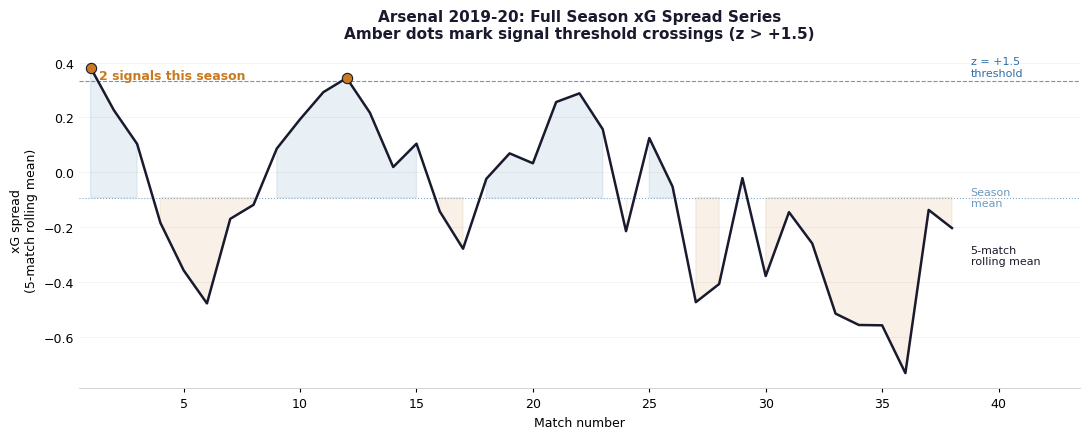

Saved nb01_fig3_full_season_spread.png  (2 signals marked)


In [23]:
# FIGURE 3 — Full season spread series: Arsenal 2019-20
# -----------------------------------------------------------------
#
#   Tufte principles applied:
#   Real data: uses team_match loaded in this notebook, not simulated
#   Single panel, full season: 38 matches — the complete picture
#   Direct labels on right margin: no legend box
#   Fill encodes sign: blue above mean, amber below
#   Signal dots use amber consistently with figure 2
#   Minimal gridlines: y-axis only, very light grey
#
#  Reads: team_match (built in Cell 4)

import matplotlib.pyplot as plt
import numpy as np

DARK  = '#1a1a2e'
BLUE  = '#2E6DA4'
AMBER = '#C97A20'
RED   = '#A93226'
GREEN = '#1E8449'
GREY  = '#666666'
LGREY = '#CCCCCC'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.6,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

# Extract Arsenal 2019-20, full 38-match season
arsenal = (
    team_match[
        (team_match['team'] == 'Arsenal') &
        (team_match['season'] == 2019)
    ]
    .sort_values('date')
    .reset_index(drop=True)
)
arsenal['match_num'] = arsenal.index + 1

x            = arsenal['match_num'].values
spread       = arsenal['rolling_spread'].values
season_mean  = spread.mean()
season_std   = spread.std()
threshold    = season_mean + 1.5 * season_std

signal_mask  = spread > threshold
signal_x     = x[signal_mask]
signal_y     = spread[signal_mask]

fig, ax = plt.subplots(figsize=(11, 4.5))

# Season mean — dotted reference, very light
ax.axhline(season_mean, color=BLUE, linewidth=0.8,
           linestyle=':', alpha=0.6, zorder=1)

# Fill above/below season mean
ax.fill_between(x, season_mean, spread,
                where=spread >= season_mean,
                alpha=0.10, color=BLUE, zorder=2)
ax.fill_between(x, season_mean, spread,
                where=spread <  season_mean,
                alpha=0.10, color=AMBER, zorder=2)

# Signal threshold line
ax.axhline(threshold, color=BLUE, linewidth=0.8,
           linestyle='--', alpha=0.7, zorder=3)

# Main spread line
ax.plot(x, spread, color=DARK, linewidth=1.8, zorder=4)

# Signal dots
if len(signal_x) > 0:
    ax.scatter(signal_x, signal_y, color=AMBER, s=55,
               zorder=5, edgecolors=DARK, linewidths=0.8)

# Direct labels on right margin
right = x[-1] + 0.8
ax.text(right, spread[-1] - 0.10,
        '5-match\nrolling mean', fontsize=8, color=DARK, va='center')
ax.text(right, threshold + 0.01,
        'z = +1.5\nthreshold', fontsize=8, color=BLUE, va='bottom')
ax.text(right, season_mean - 0.01 + 0.05,
        'Season\nmean', fontsize=8, color=BLUE, va='top', alpha=0.7)

# Signal count — top left corner
n_signals = signal_mask.sum()
if n_signals > 0:
    label = f'{n_signals} signal{"s" if n_signals != 1 else ""} this season'
    ax.text(0.02, 0.95, label,
            transform=ax.transAxes, fontsize=9,
            color=AMBER, va='top', fontweight='bold')

ax.set_xlim(0.5, x[-1] + 5.5)
ax.set_xlabel('Match number', fontsize=9)
ax.set_ylabel('xG spread\n(5-match rolling mean)', fontsize=9)
ax.yaxis.grid(True, zorder=0, linewidth=0.4, color='#EBEBEB')
ax.set_axisbelow(True)
ax.spines['bottom'].set_color(LGREY)

ax.set_title(
    'Arsenal 2019-20: Full Season xG Spread Series\n'
    'Amber dots mark signal threshold crossings (z > +1.5)',
    fontsize=11, fontweight='bold', color=DARK
)

plt.tight_layout()
plt.savefig(FIG_DIR / 'nb01_fig3_full_season_spread.png')
plt.show()
print(f"Saved nb01_fig3_full_season_spread.png  ({n_signals} signals marked)")


### Figure 3 — Arsenal 2019–20: A Full Season Spread Series

The three-panel figure above shows 10 matches. This figure shows an
entire season — all 38 matches for Arsenal 2019–20 — to give a
complete picture of what the foundational time series looks like
in practice.

Several features are worth noting:

**The spread oscillates around the season mean** (the dotted line),
pulled back by the O-U restoring force when it deviates too far.
This oscillation, rather than a random walk, is the empirical
signature of stationarity — and the basis for the signal.

**Signal threshold crossings** (amber dots) mark the matches where
the rolling spread exceeded 1.5 standard deviations above the season
mean. These are the observations that will be selected as tradeable
signals in Notebooks 05A and 05B, after the O-U model has been
fitted and validated.

**The fill above and below the mean** shows periods of persistent
under-conversion (blue) and over-conversion (amber). A team can
spend several matches on one side before the restoring force pulls
the spread back. The O-U half-life parameter — estimated in
Notebook 02 — measures how quickly this correction typically occurs.

This is the data object that all subsequent analysis is built on.
Every team has a series like this for every season they appear in
the dataset.


---
## Findings

**Leicester 2015–16:** xG/goals ratio = **1.006** — they scored almost exactly what their chances predicted. The popular "they got lucky" narrative is **not supported by the data**. The real statistical outliers in the 2015–16 season are West Brom (1.17) and Arsenal (1.13), who generated far more xG than they converted. Leicester's title win reflects genuine performance.

**Data integrity:** All 34 teams have exactly 38 matches per season across all 10 seasons. No gaps; the pipeline is clean.

**Man City 2023:** Raw spreads oscillate match-to-match as expected. The rolling mean stabilises within 5 matches. Z-scores are well-behaved. The spread series construction is working correctly.

---

## Output Files

| File | Shape | Description |
|---|---|---|
| `pl_match_xg_clean.csv` | (3800, 9) | Parsed match-level xG and goals |
| `pl_team_match_spread.csv` | (7600, 11) | Team-level long format with spread series |

**Next:** `02_ou_estimation.ipynb` — fit the Ornstein-Uhlenbeck model to each team's spread series.

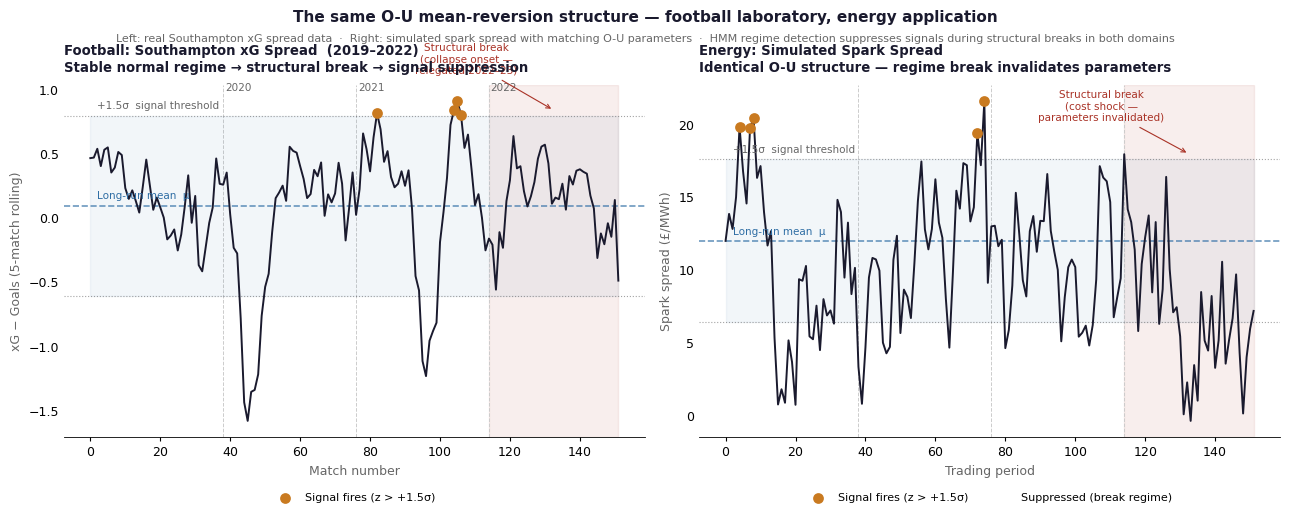

Saved → fig0_energy_analogy.png


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path().resolve().parent
FIG_DIR     = PROJECT_DIR / "figures"
DATA_DIR    = PROJECT_DIR / "data"

DARK  = '#1a1a2e'
BLUE  = '#2E6DA4'
AMBER = '#C97A20'
RED   = '#A93226'
GREY  = '#666666'
LGREY = '#CCCCCC'

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.6,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

# ── Load Southampton data ─────────────────────────────────────────
tm  = pd.read_csv(DATA_DIR / "pl_team_match_spread.csv", parse_dates=['date'])
hmm = pd.read_csv(DATA_DIR / "pl_hmm_regimes.csv",       parse_dates=['date'])

sou     = (tm[tm['team'] == 'Southampton']
           .sort_values('date')
           .dropna(subset=['rolling_spread'])
           .reset_index(drop=True))

sou_hmm = (hmm[hmm['team'] == 'Southampton']
           .sort_values('date')
           .reset_index(drop=True))

# ── Filter to 2019–2022 ───────────────────────────────────────────
mask    = sou['season'].isin([2019, 2020, 2021, 2022])
sou_w   = sou[mask].copy().reset_index(drop=True)

mask_h  = sou_hmm['season'].isin([2019, 2020, 2021, 2022])
sou_w_h = sou_hmm[mask_h].copy().reset_index(drop=True)

# Merge regime onto spread data
sou_w = sou_w.merge(
    sou_w_h[['date', 'regime']],
    on='date', how='left'
)

mu_sou    = sou_w['rolling_spread'].mean()
sigma_sou = sou_w['rolling_spread'].std()
upper_sou = mu_sou + 1.5 * sigma_sou
lower_sou = mu_sou - 1.5 * sigma_sou

# Break regime: 2022 season start — find index where 2022 begins
break_start_sou = sou_w[sou_w['season'] == 2022].index[0]
break_end_sou   = sou_w[sou_w['season'] == 2022].index[-1]

# Signal fires — strong long only, outside break regime
signals_sou = sou_w[sou_w['rolling_spread'] > upper_sou]
valid_sig_sou = signals_sou[
    ~((signals_sou.index >= break_start_sou) &
      (signals_sou.index <= break_end_sou))
]
break_sig_sou = signals_sou[
    (signals_sou.index >= break_start_sou) &
    (signals_sou.index <= break_end_sou)
]

# ── Simulate spark spread ─────────────────────────────────────────
np.random.seed(42)
n        = len(sou_w)
theta    = 0.28
mu_sp    = 12.0
sigma_sp = sigma_sou * 8
dt       = 1.0

# Break regime aligned proportionally with Southampton's 2022 onset
break_start_sp = break_start_sou
break_end_sp   = break_end_sou

spark = np.zeros(n)
spark[0] = mu_sp
for i in range(1, n):
    regime_shift = -5.0 if break_start_sp <= i <= break_end_sp else 0.0
    spark[i] = (spark[i-1]
                + theta * (mu_sp + regime_shift - spark[i-1]) * dt
                + sigma_sp * np.sqrt(dt) * np.random.randn())

upper_sp   = mu_sp + 1.5 * sigma_sp
lower_sp   = mu_sp - 1.5 * sigma_sp
signals_sp = np.where(spark > upper_sp)[0]

valid_signals_sp = [i for i in signals_sp
                    if not (break_start_sp <= i <= break_end_sp)]
break_signals_sp = [i for i in signals_sp
                    if break_start_sp <= i <= break_end_sp]

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel 1: Southampton xG spread ───────────────────────────────
ax = axes[0]

# Break regime shading — full 2022 season
ax.axvspan(break_start_sou, break_end_sou,
           alpha=0.08, color=RED, zorder=0)

# Season boundary lines and labels
for season in sou_w['season'].unique()[1:]:
    idx = sou_w[sou_w['season'] == season].index[0]
    ax.axvline(idx, color=LGREY, lw=0.7, ls='--', zorder=0)
    ax.text(idx + 0.5, upper_sou + sigma_sou * 0.55,
            str(season), fontsize=7.5, color=GREY, va='top')

# Bands and mean
ax.fill_between(sou_w.index, lower_sou, upper_sou,
                alpha=0.06, color=BLUE, zorder=0)
ax.axhline(mu_sou,    color=BLUE, lw=1.2, ls='--', alpha=0.7, zorder=1)
ax.axhline(upper_sou, color=GREY, lw=0.8, ls=':',  alpha=0.6, zorder=1)
ax.axhline(lower_sou, color=GREY, lw=0.8, ls=':',  alpha=0.6, zorder=1)

# Spread series
ax.plot(sou_w.index, sou_w['rolling_spread'],
        color=DARK, lw=1.4, zorder=2)

# Signal fires — valid
ax.scatter(valid_sig_sou.index, valid_sig_sou['rolling_spread'],
           color=AMBER, s=60, zorder=4, linewidths=0,
           label='Signal fires (z > +1.5σ)')

# Signal fires — suppressed
if len(break_sig_sou) > 0:
    ax.scatter(break_sig_sou.index, break_sig_sou['rolling_spread'],
               color=RED, s=60, zorder=4, linewidths=0,
               marker='x', label='Suppressed (break regime)')

# Break label
mid_break = (break_start_sou + break_end_sou) / 2
ax.annotate(
    'Structural break\n(collapse onset —\nrelegated 2022–23)',
    xy=(mid_break, upper_sou + sigma_sou * 0.1),
    xytext=(mid_break - 25, upper_sou + sigma_sou * 0.7),
    fontsize=7.5, color=RED, ha='center',
    arrowprops=dict(arrowstyle='->', color=RED, lw=0.8)
)

# Reference labels
ax.text(2, mu_sou + 0.04, 'Long-run mean  μ',
        fontsize=7.5, color=BLUE, va='bottom')
ax.text(2, upper_sou + 0.04, '+1.5σ  signal threshold',
        fontsize=7.5, color=GREY, va='bottom')

ax.set_xlabel('Match number', fontsize=9, color=GREY)
ax.set_ylabel('xG − Goals (5-match rolling)', fontsize=9, color=GREY)
ax.set_title(
    'Football: Southampton xG Spread  (2019–2022)\n'
    'Stable normal regime → structural break → signal suppression',
    fontsize=9.5, fontweight='bold', color=DARK, loc='left'
)
ax.legend(fontsize=8, frameon=False, loc='upper center',
          bbox_to_anchor=(0.5, -0.13), ncol=2)

# ── Panel 2: Simulated spark spread ──────────────────────────────
ax2 = axes[1]

x = np.arange(n)

ax2.axvspan(break_start_sp, break_end_sp,
            alpha=0.08, color=RED, zorder=0)

# Season boundary lines (mirrored)
for season in sou_w['season'].unique()[1:]:
    idx = sou_w[sou_w['season'] == season].index[0]
    ax2.axvline(idx, color=LGREY, lw=0.7, ls='--', zorder=0)

ax2.fill_between(x, lower_sp, upper_sp,
                 alpha=0.06, color=BLUE, zorder=0)
ax2.axhline(mu_sp,    color=BLUE, lw=1.2, ls='--', alpha=0.7, zorder=1)
ax2.axhline(upper_sp, color=GREY, lw=0.8, ls=':',  alpha=0.6, zorder=1)
ax2.axhline(lower_sp, color=GREY, lw=0.8, ls=':',  alpha=0.6, zorder=1)

ax2.plot(x, spark, color=DARK, lw=1.4, zorder=2)

if valid_signals_sp:
    ax2.scatter(valid_signals_sp, spark[valid_signals_sp],
                color=AMBER, s=60, zorder=4, linewidths=0,
                label='Signal fires (z > +1.5σ)')

if break_signals_sp:
    ax2.scatter(break_signals_sp, spark[break_signals_sp],
                color=RED, s=60, zorder=4, linewidths=0,
                marker='x', label='Suppressed (break regime)')

# Break label
mid_sp = (break_start_sp + break_end_sp) / 2
ax2.annotate(
    'Structural break\n(cost shock —\nparameters invalidated)',
    xy=(mid_sp, upper_sp + sigma_sp * 0.1),
    xytext=(mid_sp - 25, upper_sp + sigma_sp * 0.7),
    fontsize=7.5, color=RED, ha='center',
    arrowprops=dict(arrowstyle='->', color=RED, lw=0.8)
)

ax2.text(2, mu_sp + sigma_sp * 0.08, 'Long-run mean  μ',
         fontsize=7.5, color=BLUE, va='bottom')
ax2.text(2, upper_sp + sigma_sp * 0.08, '+1.5σ  signal threshold',
         fontsize=7.5, color=GREY, va='bottom')

ax2.set_xlabel('Trading period', fontsize=9, color=GREY)
ax2.set_ylabel('Spark spread (£/MWh)', fontsize=9, color=GREY)
ax2.set_title(
    'Energy: Simulated Spark Spread\n'
    'Identical O-U structure — regime break invalidates parameters',
    fontsize=9.5, fontweight='bold', color=DARK, loc='left'
)
ax2.legend(fontsize=8, frameon=False, loc='upper center',
           bbox_to_anchor=(0.5, -0.13), ncol=2)

# ── Connecting header ─────────────────────────────────────────────
fig.text(0.5, 1.01,
         'The same O-U mean-reversion structure — football laboratory, energy application',
         ha='center', fontsize=11, fontweight='bold', color=DARK)
fig.text(
    0.5, 0.97,
    'Left: real Southampton xG spread data  ·  '
    'Right: simulated spark spread with matching O-U parameters  ·  '
    'HMM regime detection suppresses signals during structural breaks in both domains',
    ha='center', fontsize=8, color=GREY
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig(FIG_DIR / 'fig0_energy_analogy.png', bbox_inches='tight')
plt.show()
print("Saved → fig0_energy_analogy.png")